# Banking Risk Analysis

## Problem Statement

Develop a basic understanding of risk analytics in banking and financial services and understand how data is used to minimise the risk of losing money while lending to customers.

## Solution

With our dashboards, created using the latest Power BI tools, the company can make informed decisions based on the applicant’s profile. If the applicant is likely to repay the loan, the loan is approved; otherwise, it is not.

## Dataset Description

- **BRId**: Branch ID  
    - 1: Retail branch  
    - 2: Institutional branch  
    - 3: Corporate branch  
    - 4: Private branch  

- **GenderId**:  
    - 1: Male  
    - 2: Female  

- **ARId**: Advisor ID  
    - 1: Alex Morgan  
    - 2: Jordan Lee  
    - 3: Taylor Smith  
    - 4: Morgan Brown  
    - 5: Casey Johnson  
    - 6: Jamie Clark  
    - 7: Riley Davis  
    - 8: Avery Martinez  
    - 9: Peyton Kim  
    - 10: Drew Patel  


We would be importing the data from SQL Workbench where I have created a database 'banking_analysis' and table 'customer'. The data is also shown in the data folder.

Importing data from SQL:

In [50]:
from sqlalchemy import create_engine
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}")

df = pd.read_sql('SELECT * FROM banking_analysis.customers', con=engine)

df.head()


,client_id,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [43]:
df.head()

,client_id,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [45]:
df.isnull().sum()

client_id                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

As there are no null characters, but there are column name of Client which has random variables, changed that to Client_ID.

In [46]:
df.head()

,client_id,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [47]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


# Now comes the **EDA and Data Processing**

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Now, here we can see that the 'Estimated income' is a numerical value but we can make it into categorical value.
Since, min value = 15919.48 and max value = 522330.26, we can categorized it as **0-9999 as very low**, **10000-49999 as low**, **50000-99999 as medium**, **100000-499999 as high** and **>500000 as very high**.

<Axes: title={'center': 'Income Category Distribution'}, xlabel='Income Category'>

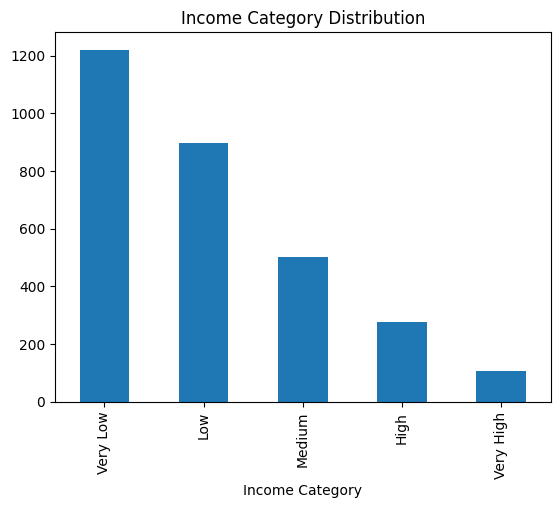

In [49]:
bins = [0, 10000, 50000, 100000, 500000, float('inf')]
df['Income Category'] = pd.cut(df['Estimated Income'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

df['Income Category'].value_counts()
df['Income Category'].value_counts().plot(kind='bar', title='Income Category Distribution')

### Univariate Analysis

In [53]:
print(df.columns)

Index(['client_id', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')


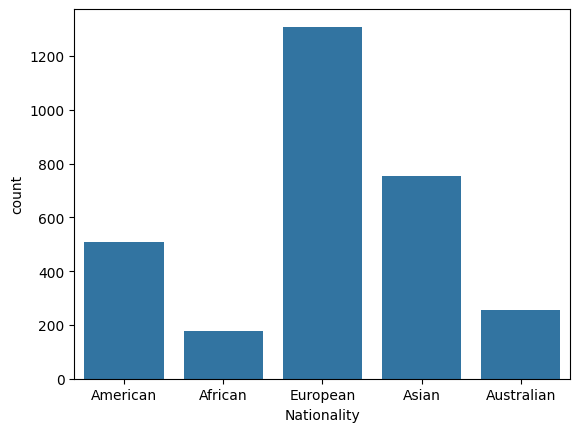

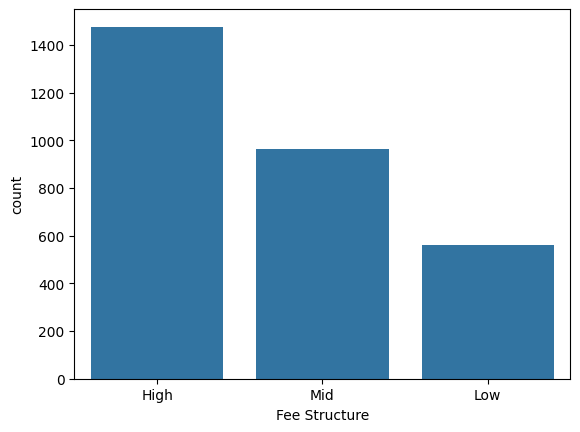

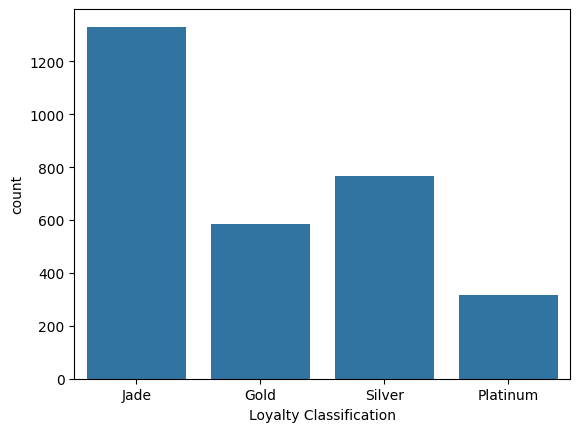

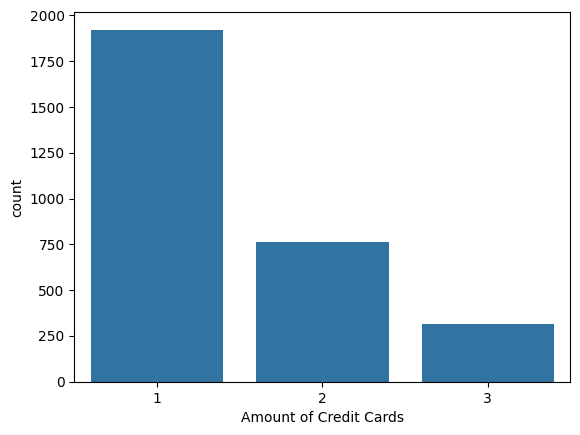

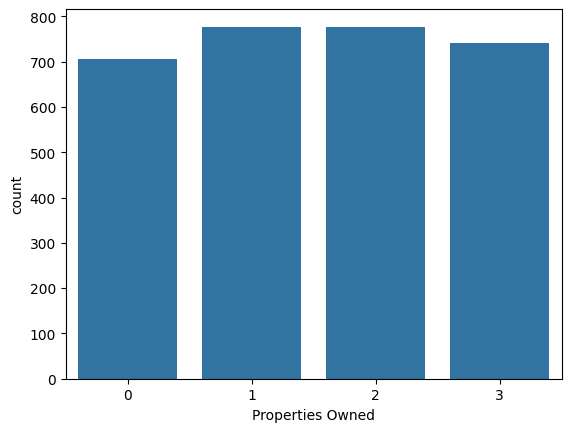

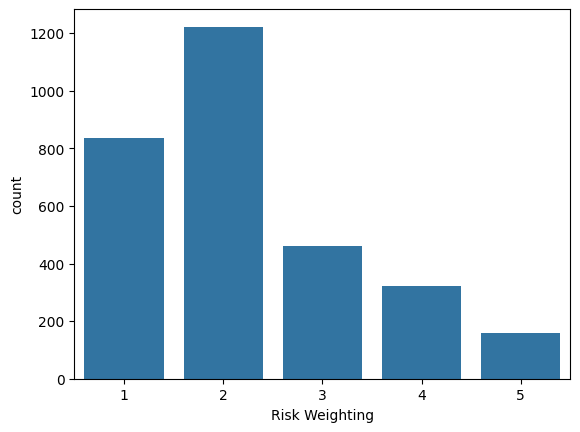

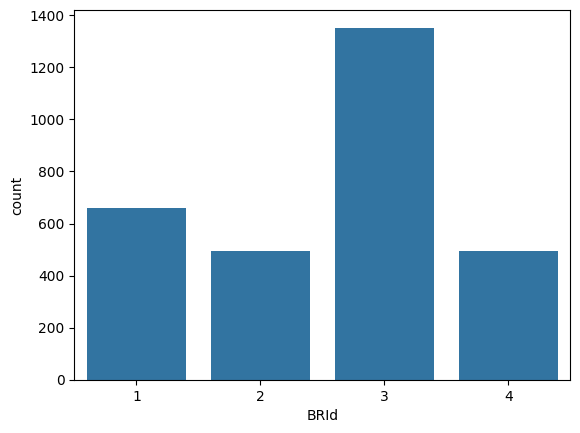

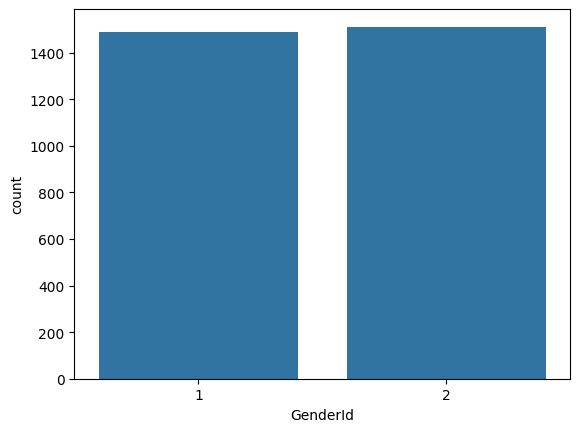

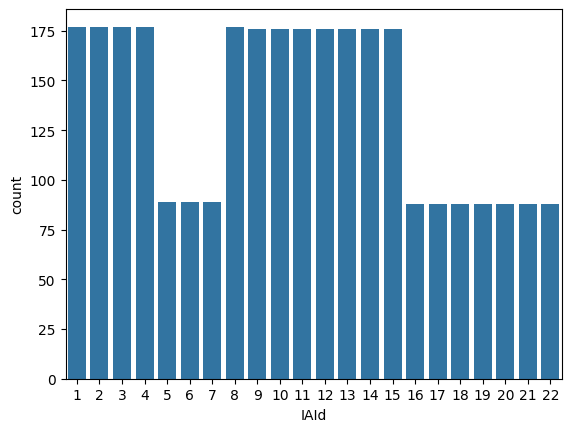

In [ ]:
for i, predictor in enumerate(df[['Nationality',  'Fee Structure', 'Loyalty Classification', 'Amount of Credit Cards', 'Properties Owned', 'Risk Weighting', 'BRId', 'GenderId', 'IAId']]):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

## Bivariate Aanalysis


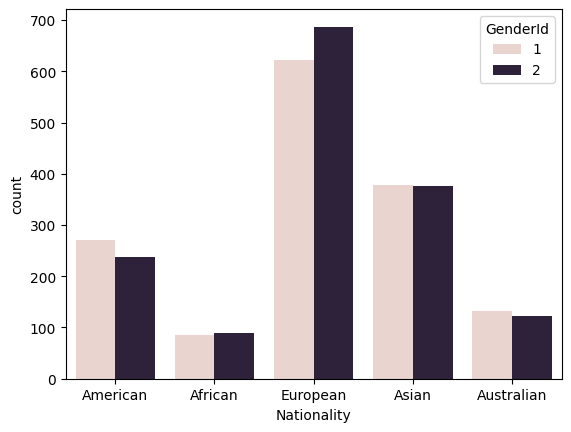

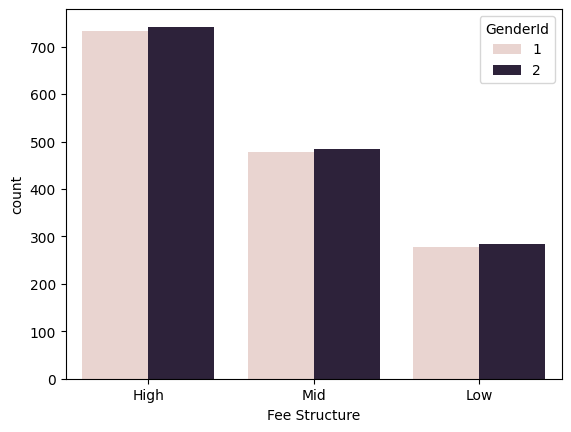

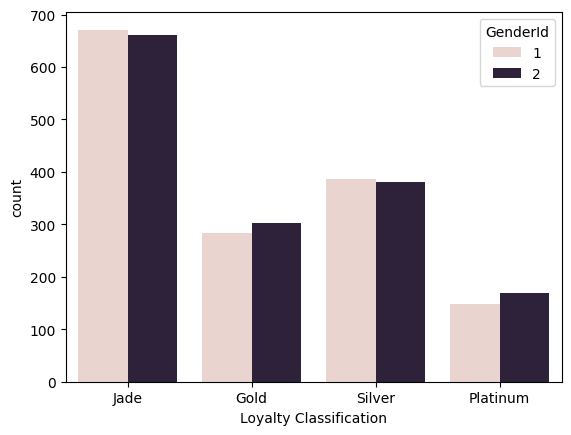

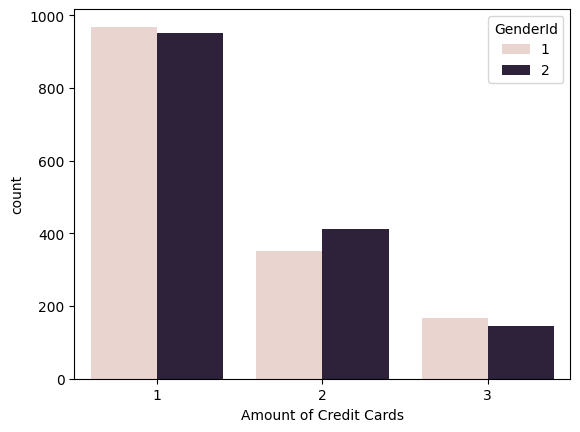

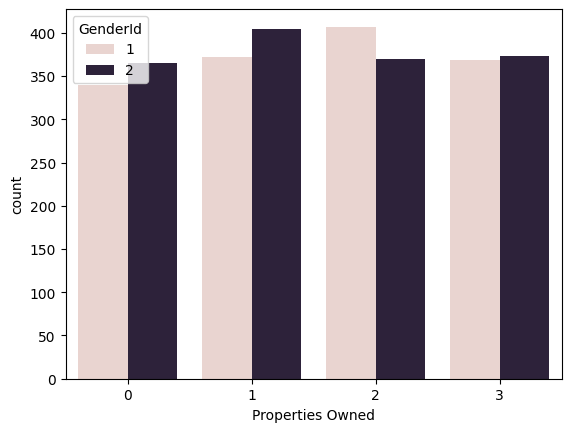

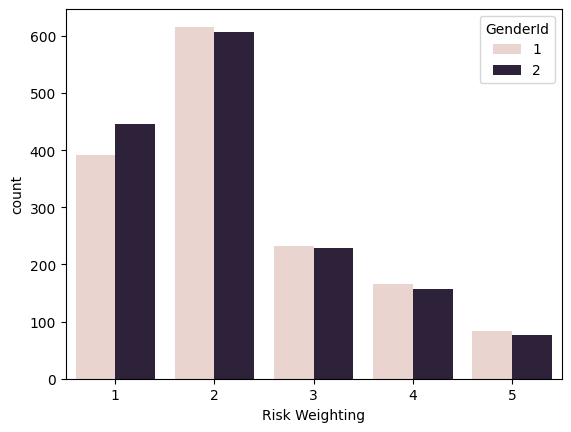

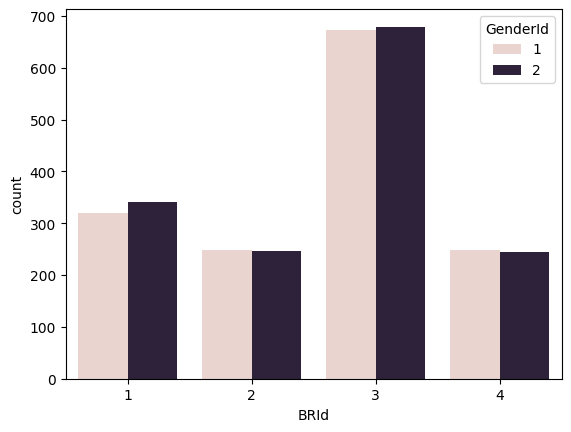

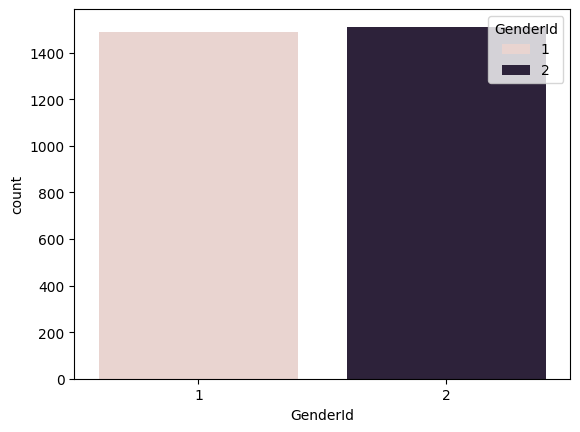

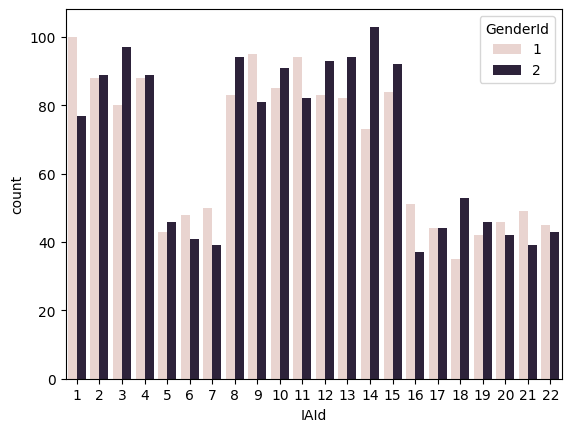

In [82]:
for i, predictor in enumerate(df[['Nationality',  'Fee Structure', 'Loyalty Classification', 'Amount of Credit Cards', 'Properties Owned', 'Risk Weighting', 'BRId', 'GenderId', 'IAId']]):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='GenderId')

## Numerical Analysis

In [71]:
df.columns

Index(['client_id', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

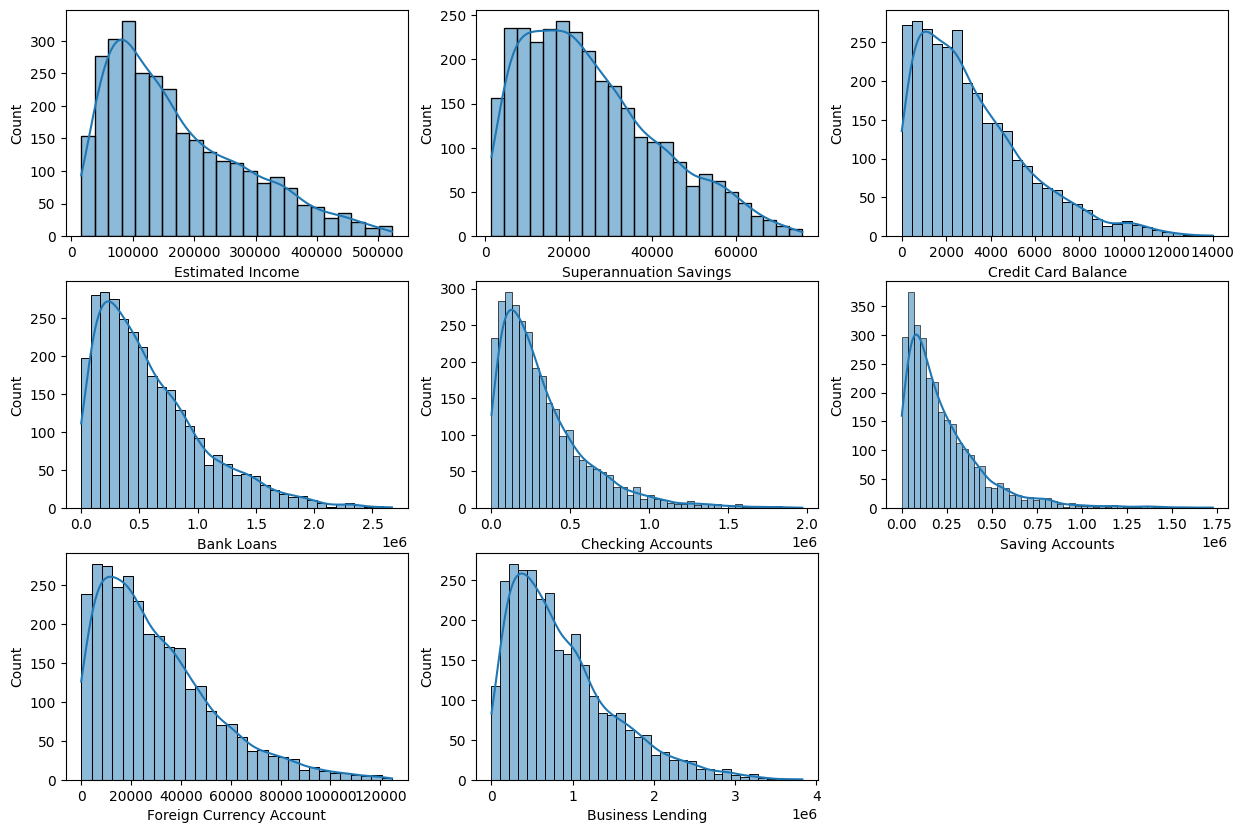

In [74]:
plt.figure(figsize=(15,10))
new_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']
for i, predictor in enumerate(new_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(data=df, kde=True, x=predictor)
    plt.ylabel('Count')
plt.show()

## Correlation Matrix


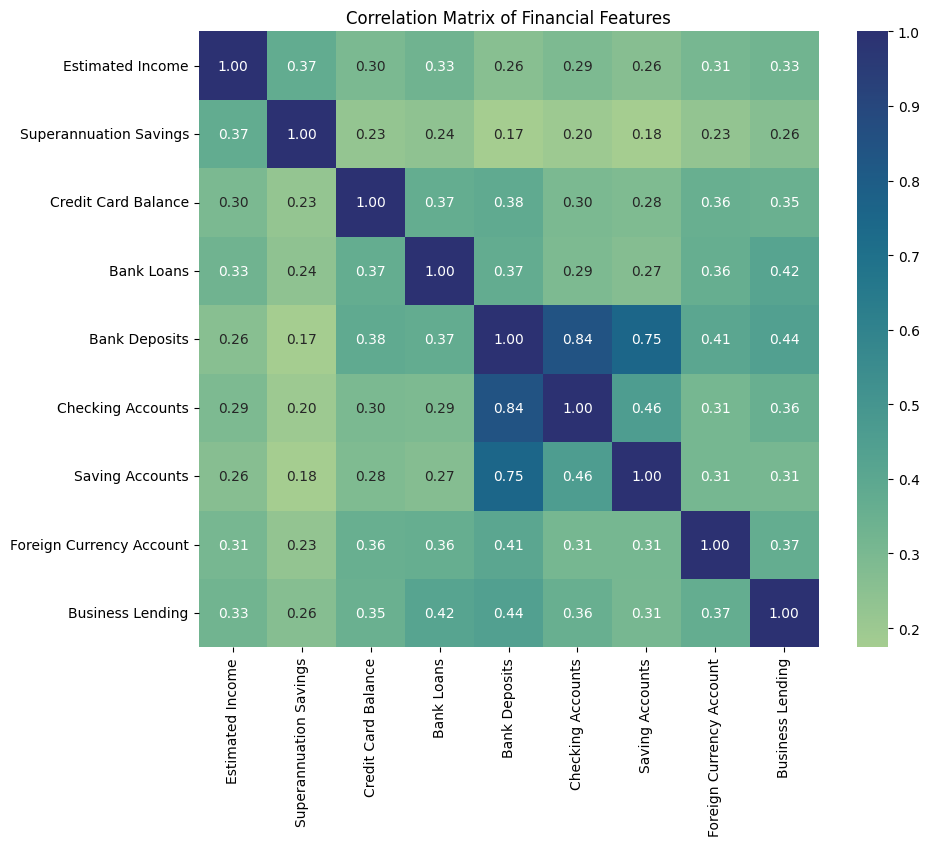

In [81]:
cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

corr = df[cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='crest', fmt=".2f")
plt.title('Correlation Matrix of Financial Features')
plt.show()

This chart shows which financial behaviors happen together, helping the bank understand who is stable and who might be risky.

### Summary of Observations

- Customers with higher **bank deposits** generally maintain higher balances in **checking** and **savings accounts**, indicating financially stable behavior.
- **Loans, credit card balances, and business lending** show moderate correlation, suggesting that customers who borrow in one product often borrow across multiple products.
- **Estimated income** has a weak relationship with credit card usage, meaning spending behavior is not solely dependent on income level.
- Overall, financial products tend to cluster together, helping distinguish **low-risk customers with strong savings** from **higher-risk customers with multiple debt obligations**.
